<a href="https://colab.research.google.com/github/sheliter/Assignment/blob/main/Homework_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 01: Binary Classification with Neural Networks

## Due: Sunday January 25 @ 11:59 (with 2-hour grace period) and worth 85 points

In this assignment, you'll build your first deep learning models using **Keras**, a high-level deep learning framework built on TensorFlow.

We’ll solve a binary classification task, using the Wisconsin Breast Cancer dataset.

You’ll start by training a simple baseline model, and then explore a series of alternate network designs.  For each model, you’ll:

- Track training loss and accuracy over epochs
- Report final test set performance (loss and accuracy)

The goal is to begin developing an intuition for how network design choices influence performance—and to get comfortable with the end-to-end modeling workflow in Keras.


There are 12 graded problems, each worth 7 points, and you get 1 point free.


In [ ]:
# Useful Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Sequential

random_seed = 42

c:\Users\Owner\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Owner\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Owner\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framewo

In [ ]:
# Utility function: Plotting Training Loss (x-entropy) and Accuracy
# We'll replace this with a different function train_and_test when we develop more
# training techniques.

# Takes the history object returned by fit

def plot_history(history):
    n_epochs = len(history.history['accuracy'])
    epochs = range(1, n_epochs + 1)

    plt.figure(figsize=(7, 8))

    plt.subplot(2, 1, 1)
    plt.plot(epochs, history.history['loss'], label='Training Loss (Xent)', color='tab:red')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.grid(True)
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(epochs, history.history['accuracy'], label='Training Accuracy', color='tab:blue')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1.05)
    plt.title('Training Accuracy')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

    final_loss = history.history['loss'][-1]
    final_acc = history.history['accuracy'][-1]
    print(f'Final Training Loss:     {final_loss:.4f}')
    print(f'Final Training Accuracy: {final_acc:.4f}')


## Prelude: Load and Explore the Wisconsin Breast Cancer Dataset

You should **always** perform EDA when working with a new dataset. We've seen this one before, but its always worth becoming familiar with the data before building a model!

In [ ]:
# Load dataset with as DataFrame for EDA
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer(as_frame=True)

df = data.frame  # Convenient alias for combined data+target

In [ ]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Target name:", data.target_names)   # ['malignant', 'benign']
print("Class counts:\n", df['target'].value_counts())

Shape: (569, 31)
Columns: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'target']
Target name: ['malignant' 'benign']
Class counts:
 target
1    357
0    212
Name: count, dtype: int64


In [ ]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [ ]:
display(df.groupby('target').agg(['mean','std']).T)

target                                  0           1
mean radius             mean    17.462830   12.146524
                        std      3.203971    1.780512
mean texture            mean    21.604906   17.914762
                        std      3.779470    3.995125
mean perimeter          mean   115.365377   78.075406
                        std     21.854653   11.807438
mean area               mean   978.376415  462.790196
                        std    367.937978  134.287118
mean smoothness         mean     0.102898    0.092478
                        std      0.012608    0.013446
mean compactness        mean     0.145188    0.080085
                        std      0.053987    0.033750
mean concavity          mean     0.160775    0.046058
                        std      0.075019    0.043442
mean concave points     mean     0.087990    0.025717
                        std      0.034374    0.015909
mean symmetry           mean     0.192909    0.174186
                        std      0.027638    0.024807
mean fractal dimension  mean     0.062680    0.062867
                        std      0.007573    0.006747
radius error            mean     0.609083    0.284082
                        std      0.345039    0.112570
texture error           mean     1.210915    1.220380
                        std      0.483178    0.589180
perimeter error         mean     4.323929    2.000321
                        std      2.568546    0.771169
area error              mean    72.672406   21.135148
                        std     61.355268    8.843472
smoothness error        mean     0.006780    0.007196
                        std      0.002890    0.003061
compactness error       mean     0.032281    0.021438
                        std      0.018387    0.016352
concavity error         mean     0.041824    0.025997
                        std      0.021603    0.032918
concave points error    mean     0.015060    0.009858
                        std      0.005517    0.005709
symmetry error          mean     0.020472    0.020584
                        std      0.010065    0.006999
fractal dimension error mean     0.004062    0.003636
                        std      0.002041    0.002938
worst radius            mean    21.134811   13.379801
                        std      4.283569    1.981368
worst texture           mean    29.318208   23.515070
                        std      5.434804    5.493955
worst perimeter         mean   141.370330   87.005938
                        std     29.457055   13.527091
worst area              mean  1422.286321  558.899440
                        std    597.967743  163.601424
worst smoothness        mean     0.144845    0.124959
                        std      0.021870    0.020013
worst compactness       mean     0.374824    0.182673
                        std      0.170372    0.092180
worst concavity         mean     0.450606    0.166238
                        std      0.181507    0.140368
worst concave points    mean     0.182237    0.074444
                        std      0.046308    0.035797
worst symmetry          mean     0.323468    0.270246
                        std      0.074685    0.041745
worst fractal dimension mean     0.091530    0.079442
                        std      0.021553    0.013804

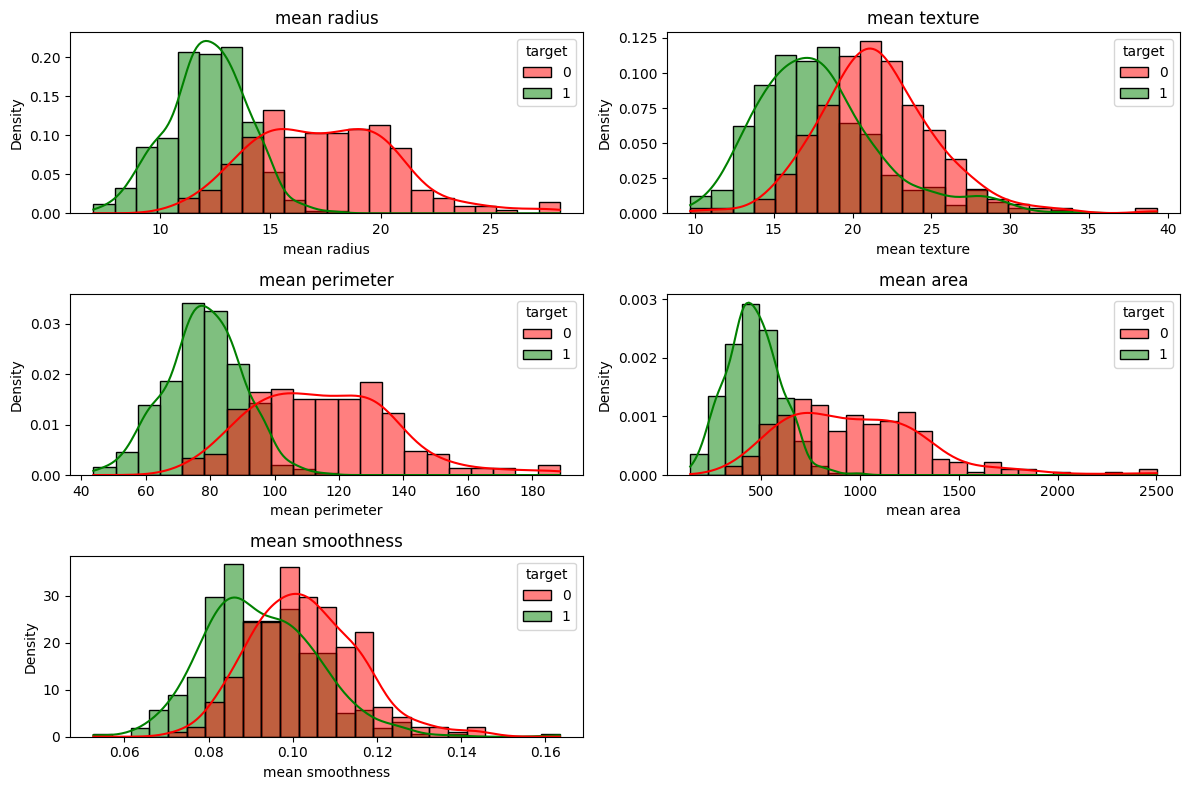

In [ ]:
selected = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']
plt.figure(figsize=(12,8))
for i, col in enumerate(selected, 1):
    plt.subplot(3,2,i)
    sns.histplot(data=df, x=col, hue='target', stat='density', common_norm=False, kde=True, palette=['r','g'])
    plt.title(col)
plt.tight_layout()
plt.show()

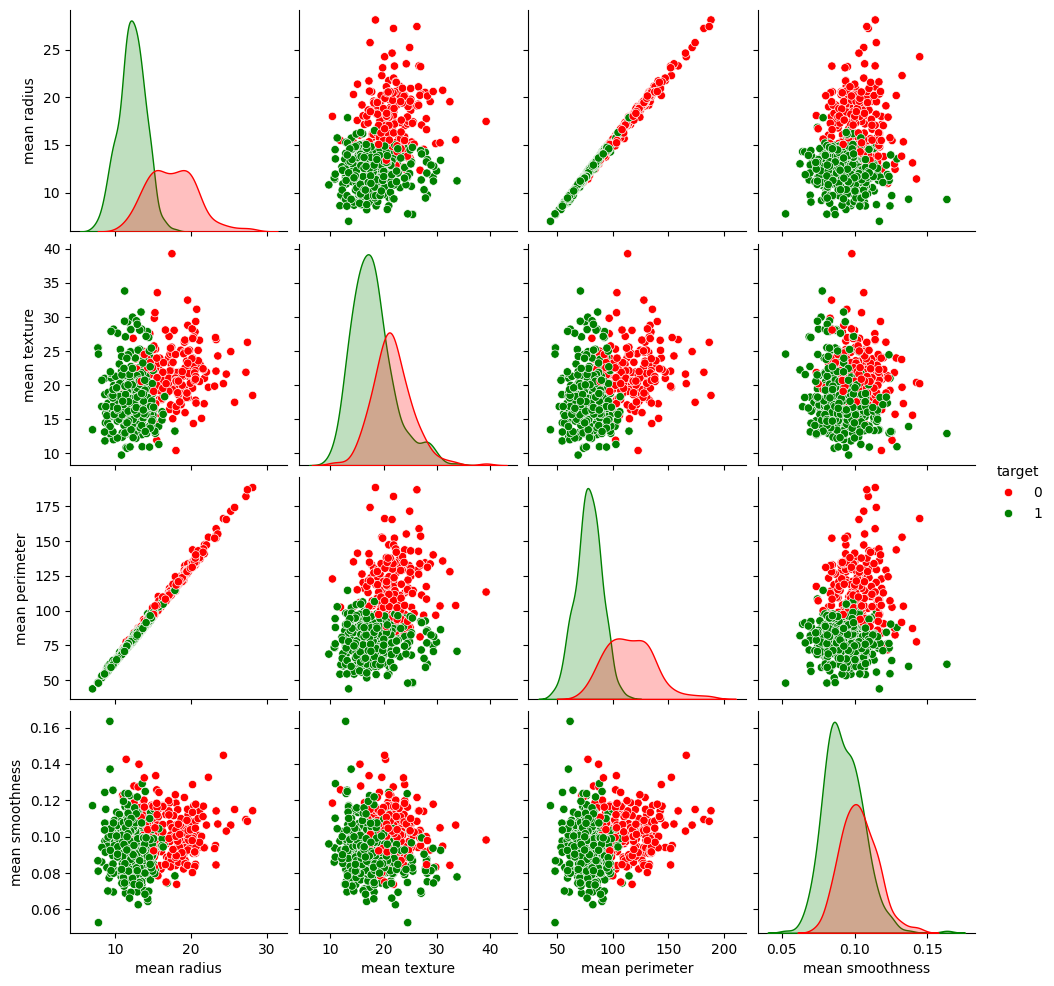

In [ ]:
sns.pairplot(df, vars=['mean radius', 'mean texture', 'mean perimeter', 'mean smoothness'], hue='target', diag_kind='kde', palette=['r','g'])
plt.show()

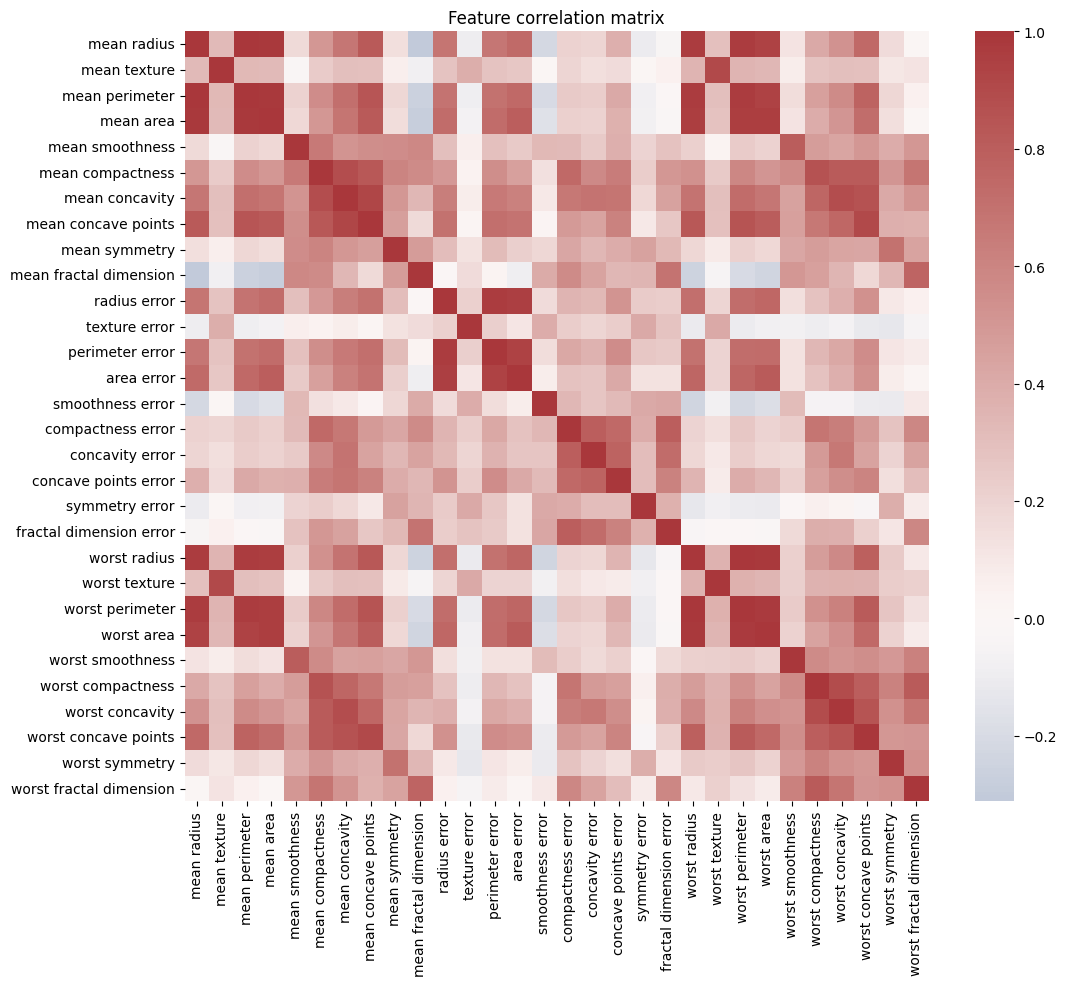

(21,
 [(np.str_('mean radius'),
   np.str_('mean perimeter'),
   np.float64(0.9978552814938109)),
  (np.str_('mean radius'),
   np.str_('mean area'),
   np.float64(0.9873571700566127)),
  (np.str_('mean radius'),
   np.str_('worst radius'),
   np.float64(0.9695389726112055)),
  (np.str_('mean radius'),
   np.str_('worst perimeter'),
   np.float64(0.9651365139559871)),
  (np.str_('mean radius'),
   np.str_('worst area'),
   np.float64(0.9410824595860461)),
  (np.str_('mean texture'),
   np.str_('worst texture'),
   np.float64(0.912044588840421)),
  (np.str_('mean perimeter'),
   np.str_('mean area'),
   np.float64(0.9865068039913907)),
  (np.str_('mean perimeter'),
   np.str_('worst radius'),
   np.float64(0.9694763634663146)),
  (np.str_('mean perimeter'),
   np.str_('worst perimeter'),
   np.float64(0.9703868870426394)),
  (np.str_('mean perimeter'),
   np.str_('worst area'),
   np.float64(0.9415498080023068)),
  (np.str_('mean area'),
   np.str_('worst radius'),
   np.float64(0.96274

In [ ]:
features = data.feature_names
corr = df[features].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='vlag', center=0)
plt.title("Feature correlation matrix")
plt.show()

# list highly correlated pairs (abs(corr) > 0.90)
high_corr_pairs = []
for i in range(len(features)):
    for j in range(i+1, len(features)):
        if abs(corr.iloc[i,j]) > 0.90:
            high_corr_pairs.append((features[i], features[j], corr.iloc[i,j]))
len(high_corr_pairs), high_corr_pairs[:20]

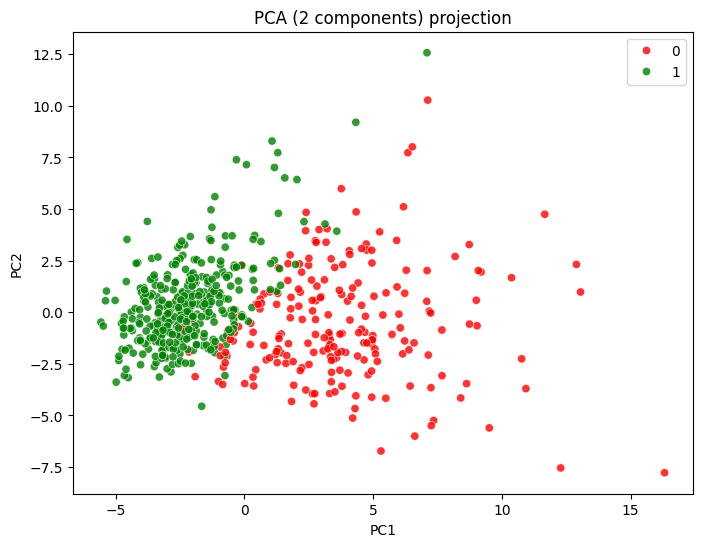

Explained variance ratio (2 PCs): [0.44272026 0.18971182] sum: 0.6324320765155944


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df[features].values
y = df['target'].values

Xs = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=random_seed)
proj = pca.fit_transform(Xs)

plt.figure(figsize=(8,6))
sns.scatterplot(x=proj[:,0], y=proj[:,1], hue=y, palette=['r','g'], alpha=0.8)
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('PCA (2 components) projection')
plt.show()
print("Explained variance ratio (2 PCs):", pca.explained_variance_ratio_, "sum:", pca.explained_variance_ratio_.sum())

In [ ]:
feat_stats = []
for col in features:
    m0 = df[df['target']==0][col]
    m1 = df[df['target']==1][col]
    pooled_std = np.sqrt(((m0.std()**2 + m1.std()**2)/2))
    effect = (m1.mean() - m0.mean()) / (pooled_std + 1e-8)
    feat_stats.append((col, effect, abs(effect)))
feat_stats_sorted = sorted(feat_stats, key=lambda x: x[2], reverse=True)
pd.DataFrame(feat_stats_sorted, columns=['feature','effect','abs_effect']).head(15)

,feature,effect,abs_effect
0,worst concave points,-2.604476,2.604476
1,worst perimeter,-2.371866,2.371866
2,mean concave points,-2.325081,2.325081
3,worst radius,-2.323756,2.323756
4,mean perimeter,-2.122999,2.122999
5,mean radius,-2.051141,2.051141
6,worst area,-1.969554,1.969554
7,mean concavity,-1.871437,1.871437
8,mean area,-1.861605,1.861605
9,worst concavity,-1.752691,1.752691


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(Xs, y, test_size=0.2, stratify=y, random_state=random_seed)

clf_lr = LogisticRegression(max_iter=2000, random_state=random_seed)
clf_lr.fit(X_train, y_train)
print("LogReg test acc:", accuracy_score(y_test, clf_lr.predict(X_test)))

clf_rf = RandomForestClassifier(n_estimators=200, random_state=random_seed)
clf_rf.fit(X_train, y_train)
print("RandomForest test acc:", accuracy_score(y_test, clf_rf.predict(X_test)))

LogReg test acc: 0.9824561403508771
RandomForest test acc: 0.956140350877193


In [ ]:
# Uncomment and look at this

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

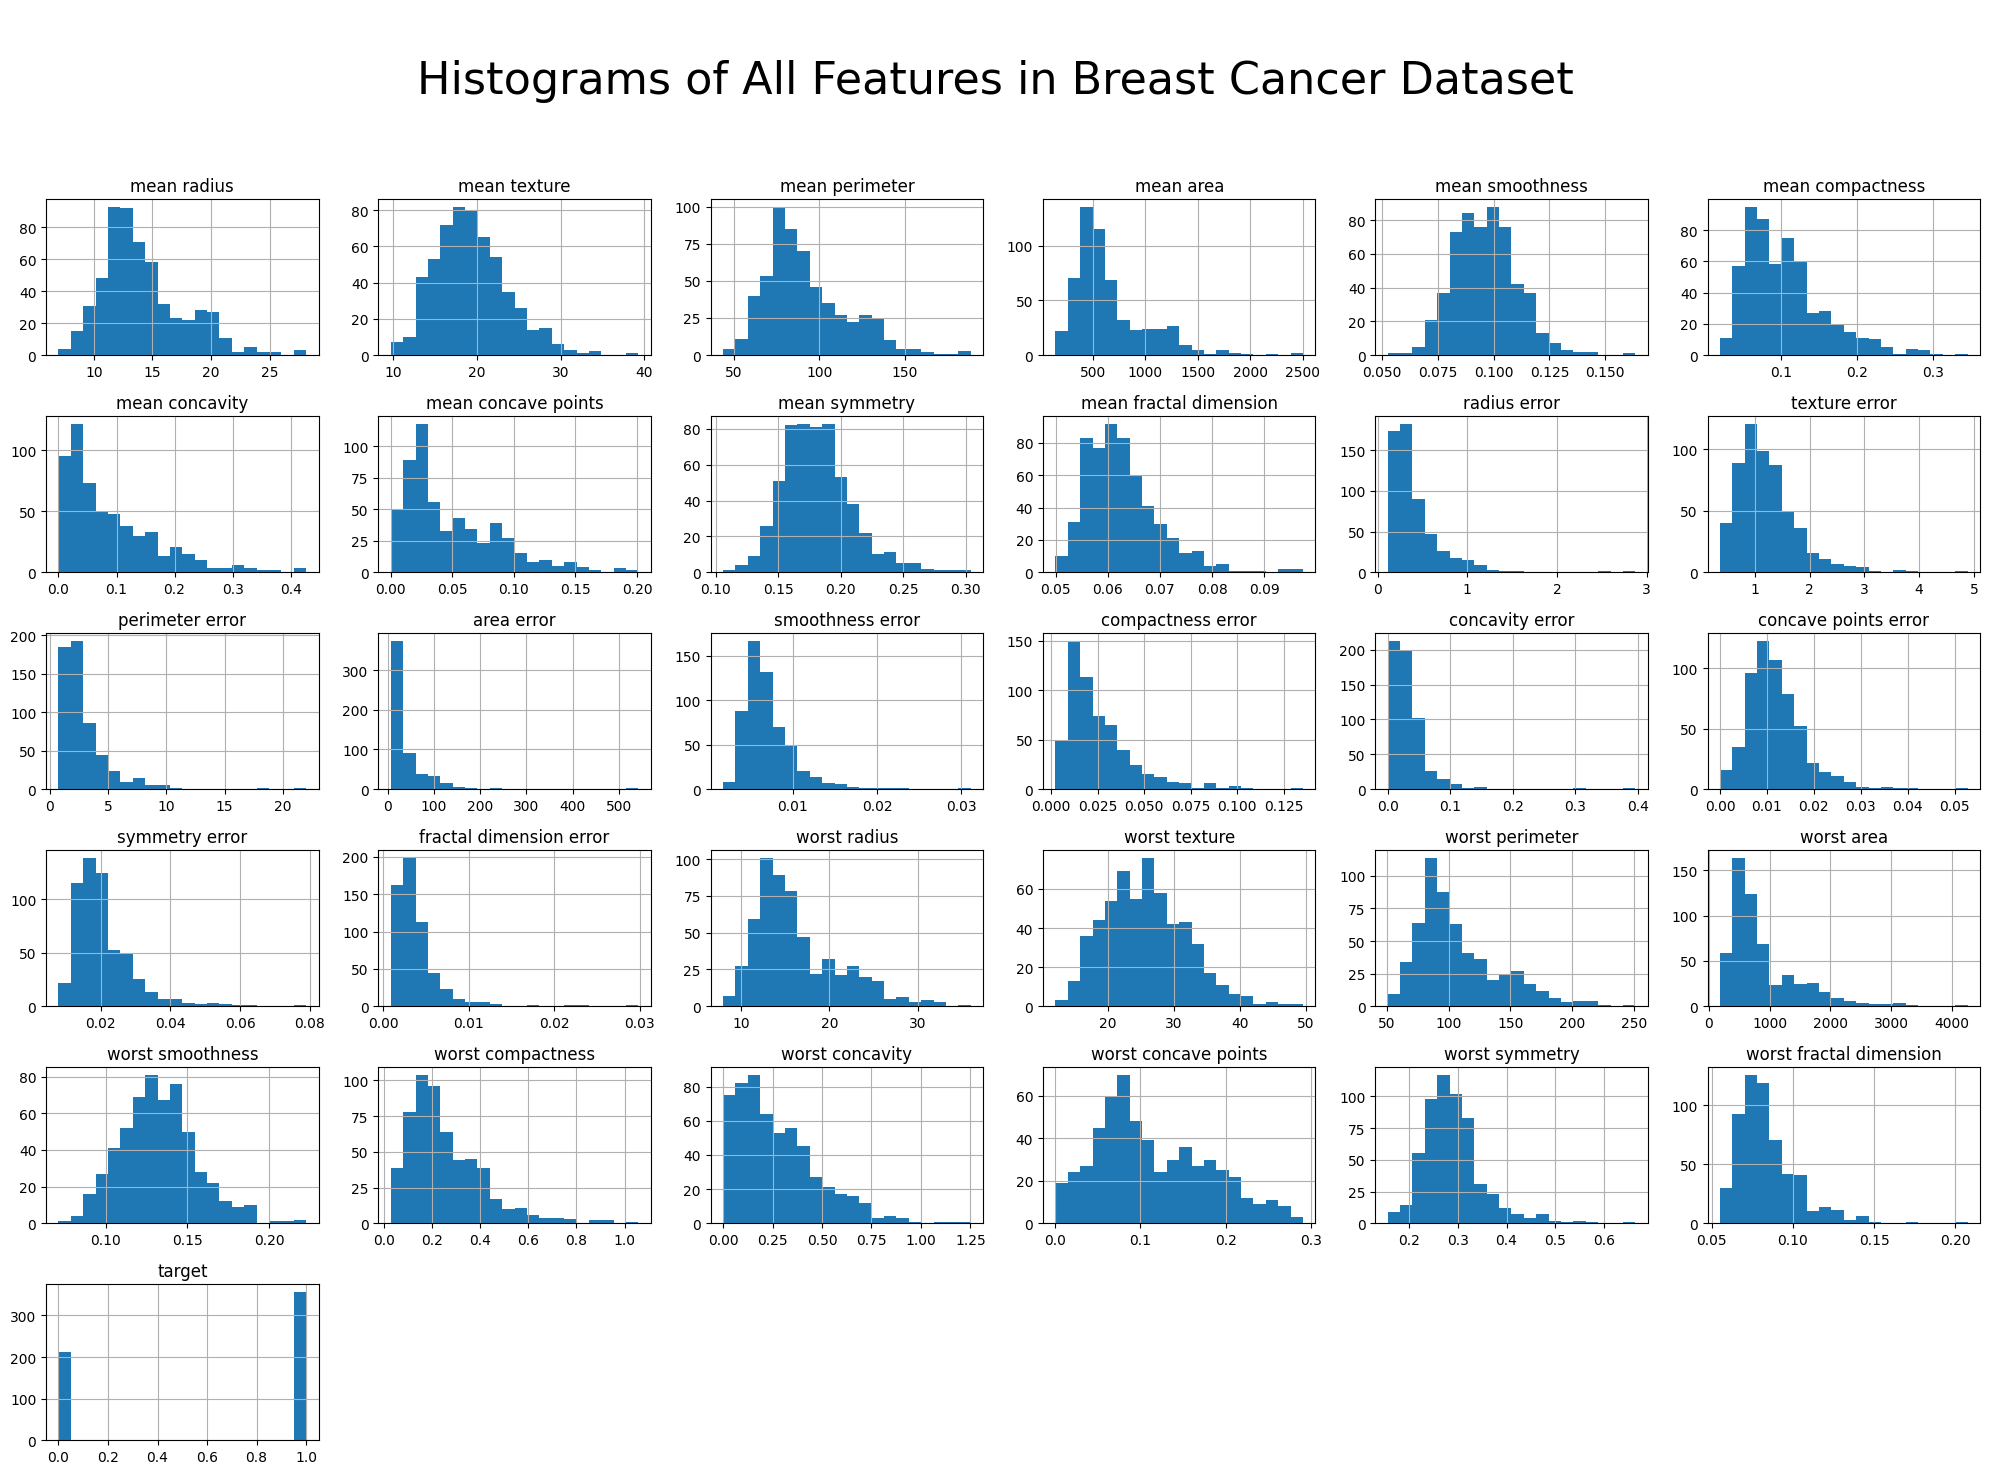

In [ ]:
# Uncomment and look at this

fig = df.hist(bins=20, figsize=(20, 15), layout=(6, 6))
plt.suptitle("\nHistograms of All Features in Breast Cancer Dataset", fontsize=32)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for the title
plt.show()

## Problem One: Dealing with unbalanced target variables and establishing a baseline model

### Part A: Compute the imbalance of the target

Neural networks work best with standardized datasets; for classification tasks, it is also important
to account for an unbalanced target. Let's create our `X,y` data structure and look at the target more closely.

1. **Convert the data to NumPy arrays:** Extract the feature matrix `X` and the target vector `y` from the DataFrame, and
convert them to NumPy arrays. Print the shapes of `X` and `y` to confirm the conversion was successful.  

2. **Check for class imbalance:**
   Use `Counter` (or another appropriate method) to print the frequency of each class label in the target array `y`. This will help you understand how balanced (or imbalanced) the classes are.

3. **Compute the proportion of class 1:**
   Calculate what percentage of the samples belong to class label `1` and provide your answer in the graded question.



In [ ]:
# A.1

X = df[features].values
y = df['target'].values

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (569, 30)
y shape: (569,)


In [ ]:
# A.2

from collections import Counter
print("Class counts:", Counter(y))

n_total = len(y)
n_class1 = int((y == 1).sum())
prop_class1 = n_class1 / n_total
percent_class1 = prop_class1 * 100.0

print(f"Class 1 count: {n_class1} / {n_total}")
print(f"Proportion of class 1: {prop_class1:.4f}")
print(f"Percentage of class 1: {percent_class1:.2f}%")

Class counts: Counter({np.int64(1): 357, np.int64(0): 212})
Class 1 count: 357 / 569
Proportion of class 1: 0.6274
Percentage of class 1: 62.74%


In [ ]:
# A.3

# Set a1a to the percentage (a float between 0 and 1) of 1's in the target
# Use an expression, not constants derived from inspecting the data

a1a = 0.0             # Replace 0.0 with your answer

In [ ]:
# A.3

# Set a1a to the percentage (a float between 0 and 1) of 1's in the target
# Use an expression, not constants derived from inspecting the data

a1a = 0.627473            # Replace 0.0 with your answer

In [ ]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a1a = {a1a:.4f}')

a1a = 0.6275


### Part B: Perform a stratified test/train split

In classification problems with imbalanced datasets, it's important to address the class imbalance so that the model doesn't become biased toward the majority class. There are two common strategies:

* **Resampling** the dataset to balance the classes (by oversampling the minority class or undersampling the majority class).
* **Adjusting the loss function** so that errors on minority classes have more influence during training.

In this problem, you'll explore the second approach—using class weights to influence how the model learns.

This strategy involves two key steps:

1. **Preserve class proportions in the train/test split**
   Use the  parameter `stratify=y`in `train_test_split` to ensure that both the training and testing sets maintain the same class distribution as in the original target.

2. **Apply class weighting during training**
   Use the `class_weight` parameter in the `fit` function to assign different weights to each class when computing the loss. This helps ensure that the model pays appropriate attention to both common and rare classes.


**We'll do the first step now, perform standardization, and then do the second step in Part C.**

In [ ]:
# Perform train-test split, keeping both stratified, use random_state = random_seed and test_size = 0.2

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import Counter
import numpy as np

# assuming X and y are your NumPy arrays from earlier
# Stratified split: keep 20% for test (you can change test_size)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

# Confirm shapes
print("Train shape:", X_train.shape, y_train.shape)
print("Test shape: ", X_test.shape, y_test.shape)

# Confirm class proportions preserved
print("Overall class counts: ", Counter(y))
print("Train class counts:   ", Counter(y_train))
print("Test class counts:    ", Counter(y_test))

# Standardize features using scaler fit on train only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Quick sanity: means (should be ~0 on train), std ~1 on train
print("Train scaled mean (per feature, approx):", np.round(X_train_scaled.mean(axis=0)[:5], 3), "...")
print("Train scaled std  (per feature, approx):", np.round(X_train_scaled.std(axis=0)[:5], 3), "...")
print("Test scaled mean (first 5 features):", np.round(X_test_scaled.mean(axis=0)[:5], 3), "...")
print("Test scaled std  (first 5 features):", np.round(X_test_scaled.std(axis=0)[:5], 3), "...")


Train shape: (455, 30) (455,)
Test shape:  (114, 30) (114,)
Overall class counts:  Counter({np.int64(1): 357, np.int64(0): 212})
Train class counts:    Counter({np.int64(1): 285, np.int64(0): 170})
Test class counts:     Counter({np.int64(1): 72, np.int64(0): 42})
Train scaled mean (per feature, approx): [-0.  0. -0.  0.  0.] ...
Train scaled std  (per feature, approx): [1. 1. 1. 1. 1.] ...
Test scaled mean (first 5 features): [0.086 0.048 0.085 0.092 0.072] ...
Test scaled std  (first 5 features): [1.033 0.876 1.029 1.095 1.208] ...


**(Digression:** We must perform standardization **after** the test/train split, or else we're letting
information about the mean and standard deviation of the test set influence training--a classic case of *data leakage*.
**)**

In [ ]:
# As usual, standardize the features

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score

# assume X, y are NumPy arrays created earlier
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20,
                                                    random_state=42, stratify=y)

pipe = Pipeline([
    ('scaler', StandardScaler()),            # fit only on X_train when pipe.fit is called
    ('clf', LogisticRegression(max_iter=2000, random_state=42))
])

# fit pipeline (scaler.fit on X_train happens inside pipe.fit)
pipe.fit(X_train, y_train)

# evaluate (scaler.transform on X_test happens inside pipe.predict)
y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)[:,1]

print("Test acc:", accuracy_score(y_test, y_pred))
print("Test AUC:", roc_auc_score(y_test, y_prob))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))



Test acc: 0.9824561403508771
Test AUC: 0.9953703703703703
Confusion matrix:
 [[41  1]
 [ 1 71]]


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

# Split (stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20,
                                                    random_state=42, stratify=y)

# Fit scaler on TRAIN ONLY, then transform train and test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Compute class weights from training labels (to pass to model.fit)
classes = np.unique(y_train)
cw_values = class_weight.compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, cw_values))
print("Class weights used for training:", class_weights)

# Build a small MLP
input_dim = X_train_scaled.shape[1]
model = Sequential([
    Input(shape=(input_dim,)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Early stopping to avoid overfitting
es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

# Train: pass class_weight so minority class has larger influence in loss
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,      # internal validation split from training set
    epochs=100,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[es],
    verbose=1
)

# Evaluate on test set (model hasn't seen X_test during scaler.fit or training)
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}, Test accuracy: {test_acc:.4f}")

Class weights used for training: {np.int64(0): np.float64(1.338235294117647), np.int64(1): np.float64(0.7982456140350878)}
Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5687 - loss: 0.6347 - val_accuracy: 0.7692 - val_loss: 0.5350
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8681 - loss: 0.4303 - val_accuracy: 0.8681 - val_loss: 0.3924
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9231 - loss: 0.3206 - val_accuracy: 0.9121 - val_loss: 0.3126
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9368 - loss: 0.2609 - val_accuracy: 0.9341 - val_loss: 0.2624
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9451 - loss: 0.2233 - val_accuracy: 0.9451 - val_loss: 0.2258
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9505 - loss: 0.1953 - val_accuracy: 0.9451 - val_loss: 0.1995
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9560 - loss: 0.1748 - val_accuracy: 0.9560 -

Let's see if the stratification worked! Assign `a1b` to the percentage of 1's in `y_train` (and convince yourself that if it is approximately correct, then so must be `y_test`).

In [ ]:
# Set a1b to the percentage (a float between 0 and 1) of 1's in the target
# Use an expression, not constants derived from inspecting the data

a1b = np.mean(y_train == 1)            # Replace 0.0 with your answer
print("As percentage:", a1b*100)  # e.g., 62.64%

As percentage: 62.637362637362635


In [ ]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a1b = {a1b:.4f}')

a1b = 0.6264


## Part C: Train a baseline model with class weighting

Now we'll build a baseline model with class weighting during training.

To compute the weight for class $i$, use the following formula:

$$
\text{weight}_i = \frac{n}{k \cdot n_i},
$$

where:

* $n$ is the total number of samples,
* $n_i$ is the number of samples in class $i$,
* $k$ is the total number of classes.

This formula scales the loss so that each class contributes approximately equally during training—without changing the number of training samples.

To apply class weighting during training, we use the parameter `class_weight=weights` in the `fit` function, where `weights` is a dictionary

    { 0 : weight_0, 1 : weight_1 }

as specified in the formula above.

**Note**: As an alternative, you can also use `sklearn.utils.class_weight` to do the calculation.

**TODO: Complete the template to**

-  Build a network consisting of a single logistic regression classifier (done for you!)
-  Compile it using the same parameters as shown in the coding video, except we will use the `Adam` optimizer:
>          optimizer='adam'
-  Train it for **100** epochs, calculating the class weights explicitly as shown or using `sklearn.utils.class_weight` (look up the docs!)
-  Display the training loss and accuracy curves using `plot_history`
-  Complete the graded question

Computed class weights: {0: np.float64(1.338235294117647), 1: np.float64(0.7982456140350878)}
Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6401 - loss: 0.6261 - val_accuracy: 0.7143 - val_loss: 0.5475
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6923 - loss: 0.5637 - val_accuracy: 0.7473 - val_loss: 0.4986
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7637 - loss: 0.5123 - val_accuracy: 0.7912 - val_loss: 0.4572
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8159 - loss: 0.4687 - val_accuracy: 0.8352 - val_loss: 0.4239
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8654 - loss: 0.4319 - val_accuracy: 0.8571 - val_loss: 0.3961
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8819 - loss: 0.4016 - val_accuracy: 0.8462 - val_loss: 0.3722
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8929 - loss: 0.3758 - val_accuracy: 0.8571 - val_loss: 0.3521
Epoch 8/10

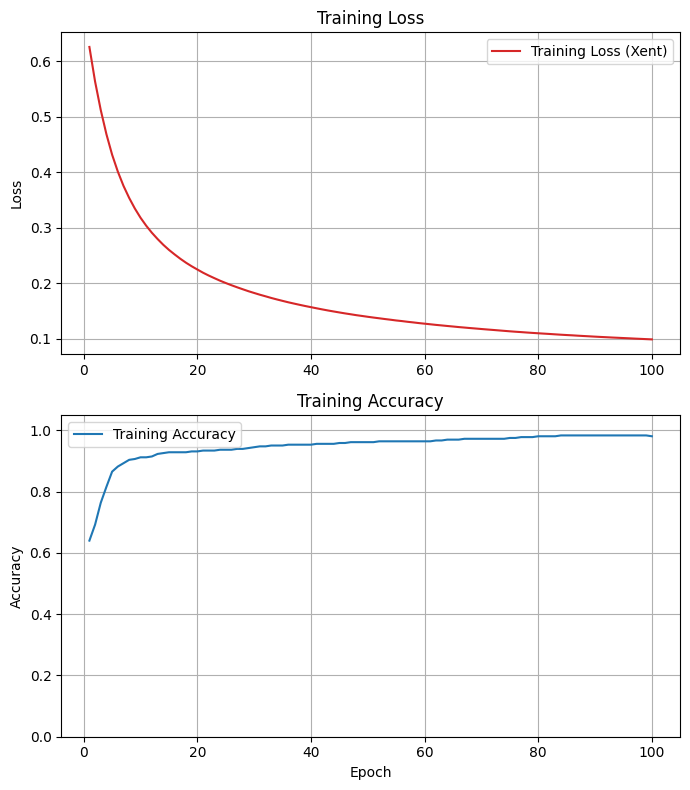

Final Training Loss:     0.0991
Final Training Accuracy: 0.9808
Test loss: 0.1277  Test accuracy: 0.9474


In [ ]:
# Try a baseline model consisting of a single logistic regression classifier.
# This is very similar to sklearn's LogisticRegression model.

n_epochs = 100

# We use Sequential to build a simple classification network from
# a list of layers, and print the summary

# Uncomment this when you have defined X_train:

'''
model_baseline = keras.Sequential(
    [
       keras.layers.Input(shape=(X_train.shape[1],)),     # Explicit input layer
       keras.layers.Dense(1, activation="sigmoid")
    ]
)
'''

import numpy as np
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from sklearn.utils import class_weight

# --- Build the logistic regression model (single Dense unit with sigmoid) ---
input_dim = X_train_scaled.shape[1]
model_lr = Sequential([
    Input(shape=(input_dim,)),
    Dense(1, activation='sigmoid')
])

# Compile with Adam optimizer and binary crossentropy
model_lr.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# --- Compute class weights using the provided formula ---
# Formula: weight_i = n / (k * n_i)
n = len(y_train)            # total number of training samples
classes, counts = np.unique(y_train, return_counts=True)
k = len(classes)            # number of classes (should be 2)

weights = {}
for cls, cnt in zip(classes, counts):
    weights[int(cls)] = n / (k * cnt)

print("Computed class weights:", weights)

# Alternatively you could use sklearn.utils.class_weight.compute_class_weight:
# cw_values = class_weight.compute_class_weight('balanced', classes=classes, y=y_train)
# weights = dict(zip(classes, cw_values))

# --- Train the model for 100 epochs with class weights ---
history_lr = model_lr.fit(
    X_train_scaled, y_train,
    validation_split=0.2,     # internal validation for plotting
    epochs=100,
    batch_size=32,
    class_weight=weights,
    verbose=1
)

# Plot training curves (your plot_history function)
plot_history(history_lr)

# Evaluate on the held-out test set (scaled with the scaler fit on training set)
test_loss, test_acc = model_lr.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}  Test accuracy: {test_acc:.4f}")




In [ ]:
# Set a1c to the final training accuracy (at epoch 100)
# You MUST use an expression here, not a constant from inspecting the results

a1c = history_lr.history['accuracy'][-1]           # Replace 0.0 with your answer

In [ ]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a1c = {a1c:.4f}')

a1c = 0.9808


### Part D: Testing

- Calculate the testing loss and accuracy and answer the graded question.
- Print out both with appropriate labels
- Answer the graded question

In [ ]:
# Your code here
# Evaluate on test set (no hard-coded numbers)
test_loss, test_acc = model_lr.evaluate(X_test_scaled, y_test, verbose=0)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
a1d_loss = test_loss
a1d_acc = test_acc
print(f"Test accuracy (percent): {test_acc * 100:.2f}%")


Test loss: 0.1277
Test accuracy: 0.9474
Test accuracy (percent): 94.74%


In [ ]:
# Set a1d to the final testing accuracy
# Use the appropriate variable; do not insert a constant from inspection of the results

a1d = test_acc          # Replace 0.0 with your answer

In [ ]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a1d = {a1d:.4f}')

a1d = 0.9474


## Problem Two: Explore alternate network designs

For the remaining problems, you will experiment with several different network designs.

For Problem Two, redo the work you did in Parts C and D of Problem One, but with a network with a single hidden layer of 16 neurons, using the sigmoid activation function, which
will have the following summary chart (the layer name may be different than shown here):

![Screenshot 2025-05-14 at 9.53.39 PM.png](attachment:289e078f-0957-43a2-b756-1b11145abf9a.png)


Then answer the graded questions.

Class weights: {0: np.float64(1.338235294117647), 1: np.float64(0.7982456140350878)}
Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8379 - loss: 0.5108 - val_accuracy: 0.8681 - val_loss: 0.4828
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8791 - loss: 0.4657 - val_accuracy: 0.8901 - val_loss: 0.4453
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8956 - loss: 0.4288 - val_accuracy: 0.9011 - val_loss: 0.4135
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9148 - loss: 0.3968 - val_accuracy: 0.9231 - val_loss: 0.3863
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9258 - loss: 0.3700 - val_accuracy: 0.9231 - val_loss: 0.3629
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9341 - loss: 0.3469 - val_accuracy: 0.9231 - val_loss: 0.3425
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9396 - loss: 0.3269 - val_accuracy: 0.9341 - val_loss: 0.3238
Epoch 8/100
12/12 ━

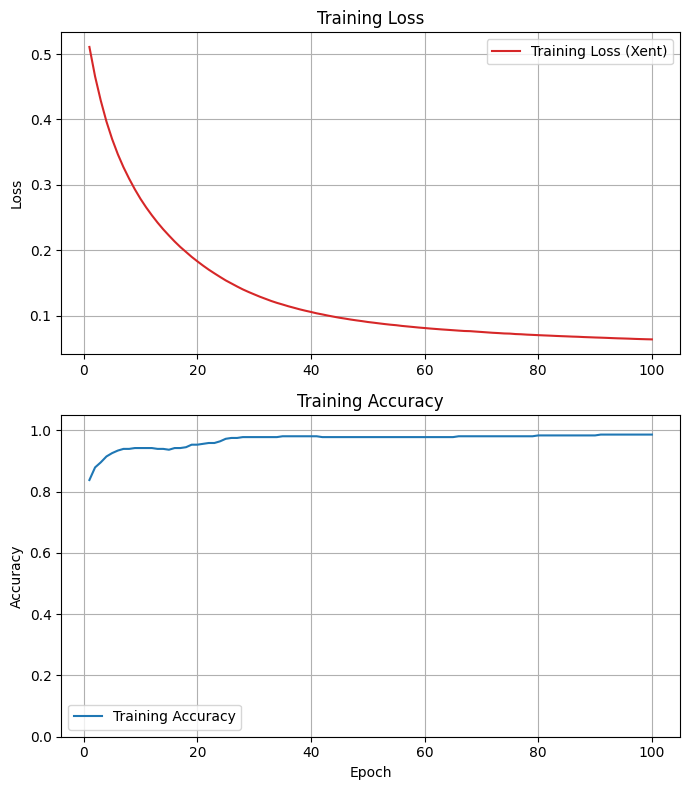

Final Training Loss:     0.0637
Final Training Accuracy: 0.9863
Test loss: 0.0996  Test accuracy: 0.9474


In [ ]:
# Your code here, add additional cells if you wish

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
import numpy as np
from sklearn.utils import class_weight

# ---- Build the model ----
input_dim = X_train_scaled.shape[1]
model_16sig = Sequential([
    Input(shape=(input_dim,)),
    Dense(16, activation='sigmoid'),
    Dense(1, activation='sigmoid')
])

# ---- Compile ----
model_16sig.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# ---- Compute class weights (fit on training labels only) ----
n = len(y_train)
classes, counts = np.unique(y_train, return_counts=True)
k = len(classes)
weights = {int(cls): n / (k * cnt) for cls, cnt in zip(classes, counts)}
print("Class weights:", weights)

# ---- Train for 100 epochs with class weights ----
history_16sig = model_16sig.fit(
    X_train_scaled, y_train,
    validation_split=0.2,   # keeps behavior similar to Part C
    epochs=100,
    batch_size=32,
    class_weight=weights,
    verbose=1
)

# ---- Plot training history (uses your plot_history function) ----
plot_history(history_16sig)

# ---- Evaluate on test set ----
test_loss_16sig, test_acc_16sig = model_16sig.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test loss: {test_loss_16sig:.4f}  Test accuracy: {test_acc_16sig:.4f}")

# ---- Set graded variables (use expressions, not constants) ----


In [ ]:
# Set a2a to the final training accuracy
# Use the appropriate variable or expression; do not insert a constant from inspection of the results

a2a = history_16sig.history['accuracy'][-1]  # final training accuracy at last epoch


In [ ]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a2a = {a2a:.4f}')

a2a = 0.9863


In [ ]:
# Set a2b to the final testing accuracy
# Use the appropriate variable; do not insert a constant from inspection of the results

a2b = test_acc_16sig                          # final test accuracy
           # Replace 0.0 with your answer           # Replace 0.0 with your answer

In [ ]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a2b = {a2b:.4f}')

a2b = 0.9474


## Problem Three: Explore alternate network designs


For Problem Three, redo the work you did in Parts C and D of Problem One, but with a network with a  hidden layer of 64 neurons,
using the sigmoid activation function, which
will have the following summary chart:

![Screenshot 2025-05-14 at 9.53.30 PM.png](attachment:1d505d45-e05e-4c0d-b125-70c1697ef5ba.png)


Then answer the graded questions.

Class weights: {0: np.float64(1.338235294117647), 1: np.float64(0.7982456140350878)}
Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.4148 - loss: 0.6925 - val_accuracy: 0.6374 - val_loss: 0.6072
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8544 - loss: 0.5210 - val_accuracy: 0.9231 - val_loss: 0.4672
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9396 - loss: 0.4113 - val_accuracy: 0.9560 - val_loss: 0.3798
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9396 - loss: 0.3437 - val_accuracy: 0.9560 - val_loss: 0.3226
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9423 - loss: 0.2956 - val_accuracy: 0.9670 - val_loss: 0.2827
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9478 - loss: 0.2618 - val_accuracy: 0.9670 - val_loss: 0.2518
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9505 - loss: 0.2360 - val_accuracy: 0.9670 - val_loss: 0.2264
Epoch 8/100
12/12 ━━━━━

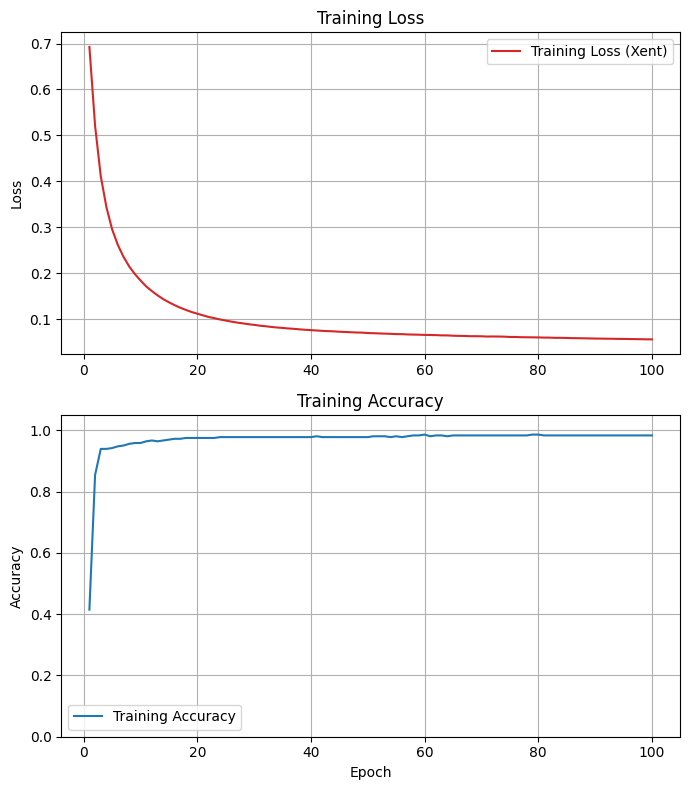

Final Training Loss:     0.0562
Final Training Accuracy: 0.9835
Test loss: 0.1027  Test accuracy: 0.9474


In [ ]:
# Your code here, add additional cells if you wish

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from sklearn.utils import class_weight
import numpy as np

# Build model: Input -> Dense(64, sigmoid) -> Dense(1, sigmoid)
input_dim = X_train_scaled.shape[1]
model_64sig = Sequential([
    Input(shape=(input_dim,)),
    Dense(64, activation='sigmoid'),
    Dense(1, activation='sigmoid')
])

# Compile (Adam + binary_crossentropy)
model_64sig.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Compute class weights from training labels using the given formula:
# weight_i = n / (k * n_i)
n = len(y_train)
classes, counts = np.unique(y_train, return_counts=True)
k = len(classes)
weights = {int(cls): n / (k * cnt) for cls, cnt in zip(classes, counts)}
print("Class weights:", weights)

# Train for 100 epochs with class weights (use validation_split=0.2 to show val curves)
history_64sig = model_64sig.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=weights,
    verbose=1
)

# Plot training history (loss and accuracy)
plot_history(history_64sig)

# Evaluate on test set
test_loss_64sig, test_acc_64sig = model_64sig.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test loss: {test_loss_64sig:.4f}  Test accuracy: {test_acc_64sig:.4f}")

# Set graded variables using expressions (no hard-coding)
a3a = history_64sig.history['accuracy'][-1]  # final training accuracy
a3d = test_acc_64sig                         # final test accuracy



In [ ]:
# Set a3a to the final training accuracy
# Use the appropriate variable or expression; do not insert a constant from inspection of the results

a3a = history_64sig.history['accuracy'][-1]           # Replace 0.0 with your answer

In [ ]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a3a = {a3a:.4f}')

a3a = 0.9835


In [ ]:
# Set a3b to the final testing accuracy
# Use the appropriate variable; do not insert a constant from inspection of the results

a3b = test_acc_64sig           # Replace 0.0 with your answer

In [ ]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a3b = {a3b:.4f}')

a3b = 0.9474


## Problem Four: Explore alternate network designs


For Problem Four, redo the work you did in Parts C and D of Problem One, but with a network with  a hidden layer of 256 neurons, using the sigmoid activation function, which
will have the following summary chart:

![Screenshot 2025-05-14 at 9.53.20 PM.png](attachment:464f1603-0ac4-4ca2-8f3e-affe3ee25b5a.png)


Then answer the graded questions.

Class weights: {0: np.float64(1.338235294117647), 1: np.float64(0.7982456140350878)}
Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8984 - loss: 0.5221 - val_accuracy: 0.9341 - val_loss: 0.3972
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9341 - loss: 0.3263 - val_accuracy: 0.9231 - val_loss: 0.2735
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9368 - loss: 0.2454 - val_accuracy: 0.9560 - val_loss: 0.2238
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9451 - loss: 0.2022 - val_accuracy: 0.9670 - val_loss: 0.1858
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9533 - loss: 0.1743 - val_accuracy: 0.9670 - val_loss: 0.1613
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9615 - loss: 0.1549 - val_accuracy: 0.9670 - val_loss: 0.1453
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9698 - loss: 0.1397 - val_accuracy: 0.9670 - val_loss: 0.1297
Epoch 8/100
12/12 ━━━

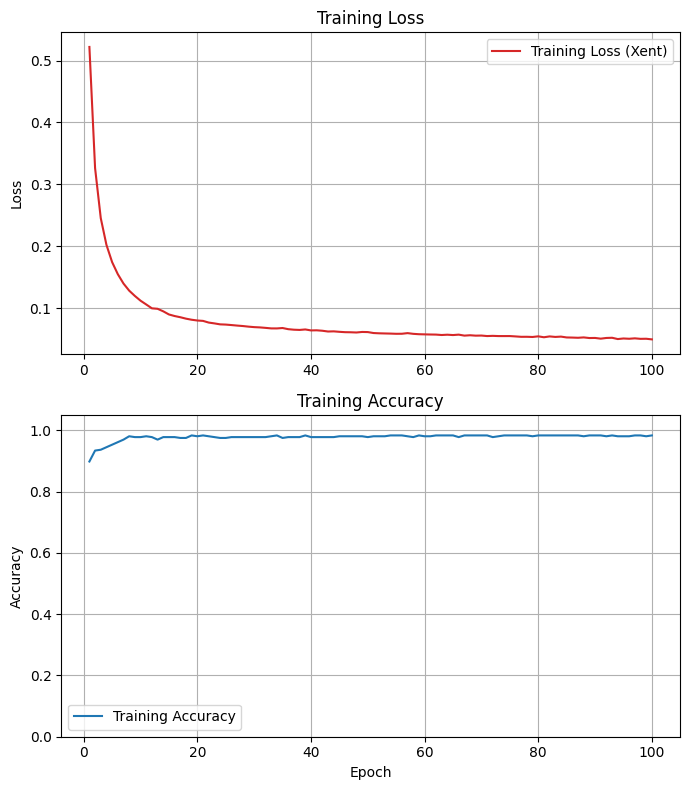

Final Training Loss:     0.0494
Final Training Accuracy: 0.9835
Test loss: 0.0937  Test accuracy: 0.9474
a4a (final training accuracy): 0.9835164546966553
a4d (final test accuracy): 0.9473684430122375


In [ ]:
# Your code here, add additional cells if you wish
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from sklearn.utils import class_weight
import numpy as np

# Build model: Input -> Dense(256, sigmoid) -> Dense(1, sigmoid)
input_dim = X_train_scaled.shape[1]
model_256sig = Sequential([
    Input(shape=(input_dim,)),
    Dense(256, activation='sigmoid'),
    Dense(1, activation='sigmoid')
])

# Compile with Adam and binary crossentropy
model_256sig.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Compute class weights from y_train using the formula weight_i = n / (k * n_i)
n = len(y_train)
classes, counts = np.unique(y_train, return_counts=True)
k = len(classes)
weights = {int(cls): n / (k * cnt) for cls, cnt in zip(classes, counts)}
print("Class weights:", weights)

# Fit for 100 epochs with class_weight and a validation split for plotting
history_256sig = model_256sig.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=weights,
    verbose=1
)

# Plot training history (loss and accuracy)
plot_history(history_256sig)

# Evaluate on the test set
test_loss_256sig, test_acc_256sig = model_256sig.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test loss: {test_loss_256sig:.4f}  Test accuracy: {test_acc_256sig:.4f}")

# Set graded variables using expressions (no hard-coded constants)
a4a = history_256sig.history['accuracy'][-1]  # final training accuracy from history
a4d = test_acc_256sig                          # final test accuracy from evaluate

# Optional: print the values
print("a4a (final training accuracy):", a4a)
print("a4d (final test accuracy):", a4d)


In [ ]:
# Set a4a to the final training accuracy
# Use the appropriate variable or expression; do not insert a constant from inspection of the results

a4a = history_256sig.history['accuracy'][-1]  # final training accuracy from history


In [ ]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a4a = {a4a:.4f}')

a4a = 0.9835


In [ ]:
# Set a4b to the final testing accuracy
# Use the appropriate variable; do not insert a constant from inspection of the results

a4b = test_acc_256sig                          # final test accuracy from evaluate
               # Replace 0.0 with your answer

In [ ]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a4b = {a4b:.4f}')

a4b = 0.9474


## Problem Five: Explore alternate network designs


For Problem Five, redo the work you did in Parts C and D of Problem One, but with a network with two hidden layers of 64  and 32 neurons, using the sigmoid activation function for all layers, which
will have the following summary chart:

![Screenshot 2025-05-14 at 9.52.42 PM.png](attachment:b6094f80-be1d-4ade-be21-44e24aab768f.png)

Then answer the graded questions.

Class weights: {0: np.float64(1.338235294117647), 1: np.float64(0.7982456140350878)}
Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.4560 - loss: 0.6636 - val_accuracy: 0.8681 - val_loss: 0.6202
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9231 - loss: 0.5785 - val_accuracy: 0.9341 - val_loss: 0.5415
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9258 - loss: 0.5054 - val_accuracy: 0.9451 - val_loss: 0.4734
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9396 - loss: 0.4348 - val_accuracy: 0.9451 - val_loss: 0.4069
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9368 - loss: 0.3719 - val_accuracy: 0.9560 - val_loss: 0.3517
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9396 - loss: 0.3172 - val_accuracy: 0.9560 - val_loss: 0.2968
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9423 - loss: 0.2751 - val_accuracy: 0.9560 - val_loss: 0.2554
Epoch 8/100
12/12 ━━━━━

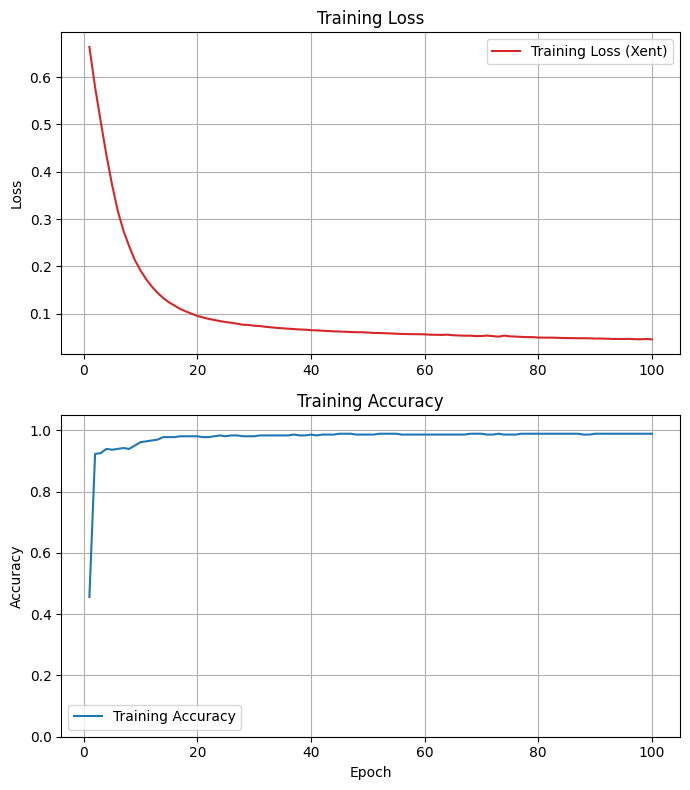

Final Training Loss:     0.0459
Final Training Accuracy: 0.9890
Test loss: 0.1178  Test accuracy: 0.9474
a5a (final training accuracy): 0.9890109896659851
a5d (final test accuracy): 0.9473684430122375


In [ ]:
# Your code here, add additional cells if you wish

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from sklearn.utils import class_weight
import numpy as np

# Build model: Input -> Dense(64, sigmoid) -> Dense(32, sigmoid) -> Dense(1, sigmoid)
input_dim = X_train_scaled.shape[1]
model_64_32_sig = Sequential([
    Input(shape=(input_dim,)),
    Dense(64, activation='sigmoid'),
    Dense(32, activation='sigmoid'),
    Dense(1, activation='sigmoid')
])

# Compile with Adam and binary crossentropy
model_64_32_sig.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Compute class weights from y_train using weight_i = n / (k * n_i)
n = len(y_train)
classes, counts = np.unique(y_train, return_counts=True)
k = len(classes)
weights = {int(cls): n / (k * cnt) for cls, cnt in zip(classes, counts)}
print("Class weights:", weights)

# Train for 100 epochs with class weights; use validation_split=0.2 so plot_history shows val curves
history_64_32_sig = model_64_32_sig.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=weights,
    verbose=1
)

# Plot training history (your function)
plot_history(history_64_32_sig)

# Evaluate on the held-out test set
test_loss_64_32_sig, test_acc_64_32_sig = model_64_32_sig.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test loss: {test_loss_64_32_sig:.4f}  Test accuracy: {test_acc_64_32_sig:.4f}")

# Set graded variables (use expressions, not hard-coded constants)


# Optionally print them
print("a5a (final training accuracy):", a5a)
print("a5d (final test accuracy):", a5d)

In [ ]:
# Set a5a to the final training accuracy
# Use the appropriate variable or expression; do not insert a constant from inspection of the results

a5a = history_64_32_sig.history['accuracy'][-1]   # final training accuracy
                         # final test accuracy            # Replace 0.0 with your answer

In [ ]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a5a = {a5a:.4f}')

a5a = 0.9890


In [ ]:
# Set a5b to the final testing accuracy
# Use the appropriate variable; do not insert a constant from inspection of the results

a5b = test_acc_64_32_sig           # Replace 0.0 with your answer

In [ ]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a5b = {a5b:.4f}')

a5b = 0.9474


## Reflection Questions:

You won't be graded on these, and you don't need to write anything, but here are some things to think about after completing the experiments.

1. After the baseline, we tried wider and wider models, and then a deeper model. Which idea worked better in terms of training accuracy (at least for this data split)? What model would you try next to test this hypothesis?

2. What effect did these experiments have on the testing accuracy?  Can you suggest an explanation for this? Rather than me giving you ideas, have a conversation with `ChatGPT` in which you describe your experiments, and the dataset, and explore with it why the testing results turned out this way.

3. What do you think would happen if you tried running the same experiments with a different random seed (and hence a different split in a fairly small dataset)?  